In [1]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
usd_inr=yf.download('USDINR=X',start='2024-01-01',end='2024-12-31',interval='1wk')

[*********************100%***********************]  1 of 1 completed


In [3]:
type(usd_inr)

pandas.DataFrame

In [4]:
usd_inr.head()

Price,Close,High,Low,Open,Volume
Ticker,USDINR=X,USDINR=X,USDINR=X,USDINR=X,USDINR=X
Date,,,,,
2024-01-01,83.240601,83.360298,83.035004,83.248596,0
2024-01-08,83.076103,83.189697,82.779099,83.191101,0
2024-01-15,83.160599,83.230797,82.809998,82.872101,0
2024-01-22,83.146103,83.222504,81.513702,83.124702,0
2024-01-29,82.927597,83.212601,82.815002,83.121300,0


In [5]:
usd_inr.columns

MultiIndex([( 'Close', 'USDINR=X'),
            (  'High', 'USDINR=X'),
            (   'Low', 'USDINR=X'),
            (  'Open', 'USDINR=X'),
            ('Volume', 'USDINR=X')],
           names=['Price', 'Ticker'])

In [6]:
usd_inr.shape

(53, 5)

In [7]:
usd_inr.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 53 entries, 2024-01-01 to 2024-12-30
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, USDINR=X)   53 non-null     float64
 1   (High, USDINR=X)    53 non-null     float64
 2   (Low, USDINR=X)     53 non-null     float64
 3   (Open, USDINR=X)    53 non-null     float64
 4   (Volume, USDINR=X)  53 non-null     int64  
dtypes: float64(4), int64(1)
memory usage: 2.5 KB


In [8]:
usd_inr.reset_index(inplace=True)

In [9]:
usd_inr.columns

MultiIndex([(  'Date',         ''),
            ( 'Close', 'USDINR=X'),
            (  'High', 'USDINR=X'),
            (   'Low', 'USDINR=X'),
            (  'Open', 'USDINR=X'),
            ('Volume', 'USDINR=X')],
           names=['Price', 'Ticker'])

In [10]:
usd_inr=usd_inr[['Date','Close']]
usd_inr.columns=[['Date','USD_INR']]

In [11]:
usd_inr.head()

,Date,USD_INR
0,2024-01-01,83.240601
1,2024-01-08,83.076103
2,2024-01-15,83.160599
3,2024-01-22,83.146103
4,2024-01-29,82.927597


In [12]:
gold_dataset=pd.read_csv("Gold vs USDINR.csv")

In [13]:
gold_dataset.head()

,Date,USD_INR,Goldrate
0,2024-01-01,83.240601,"₹5,066.31"
1,2024-01-08,83.076103,"₹4,966.31"
2,2024-01-15,83.160599,"₹5,015.33"
3,2024-01-22,83.146103,"₹4,950.84"
4,2024-01-29,82.927597,"₹4,976.77"


In [14]:
gold_dataset['Goldrate']=gold_dataset['Goldrate'].replace('₹','',regex=True).replace(',','',regex=True).astype(float)

In [15]:
gold_dataset.head()

,Date,USD_INR,Goldrate
0,2024-01-01,83.240601,5066.31
1,2024-01-08,83.076103,4966.31
2,2024-01-15,83.160599,5015.33
3,2024-01-22,83.146103,4950.84
4,2024-01-29,82.927597,4976.77


In [16]:
gold_dataset.dtypes

Date            str
USD_INR     float64
Goldrate    float64
dtype: object

# EDA

Handle missing values - No

Handle imbalanced data - No
 
Handle outliers - seen 

Encode categorical features - No 

Normalisation vs standardisation - 

<Axes: ylabel='USD_INR'>

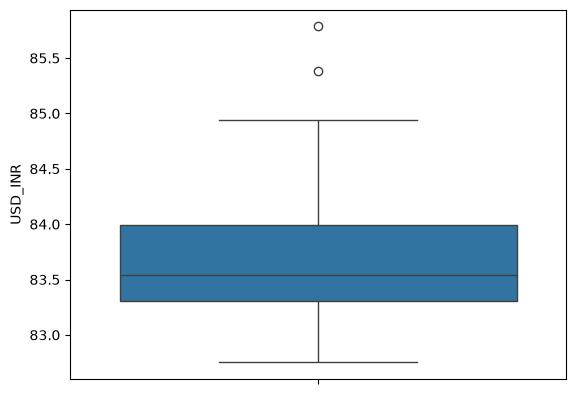

In [17]:
sns.boxplot(gold_dataset['USD_INR'])

In [18]:
gold_dataset['USD_INR'].max()

np.float64(85.78659821)

In [19]:
gold_dataset['USD_INR'].min()

np.float64(82.75229645)

<Axes: ylabel='Goldrate'>

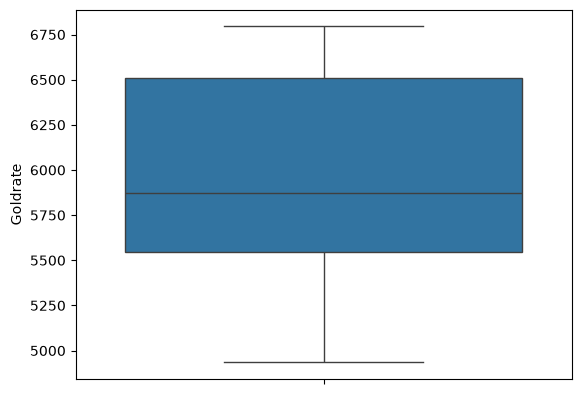

In [20]:
sns.boxplot(gold_dataset['Goldrate'])

<Axes: xlabel='USD_INR', ylabel='Goldrate'>

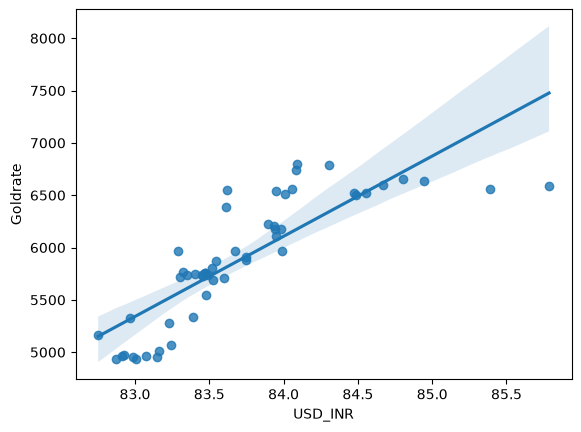

In [21]:
sns.regplot(x='USD_INR',y='Goldrate',data=gold_dataset)

# Model Training

In [22]:
x=gold_dataset[['USD_INR']]
y=gold_dataset[['Goldrate']]

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=42)

In [25]:
x_train.shape

(47, 1)

In [26]:
x_test.shape

(6, 1)

In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [29]:
from sklearn.linear_model import LinearRegression

In [30]:
regressor=LinearRegression()

In [31]:
regressor.fit(x_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[469.21]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[5878.57]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[6.86]


In [32]:
regressor.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

In [33]:
m=regressor.coef_[0][0]
b=regressor.intercept_[0]
m,b

(np.float64(469.2075576153299), np.float64(5878.573404255313))

In [34]:
x_train_predicted=regressor.predict(x_train_scaled)

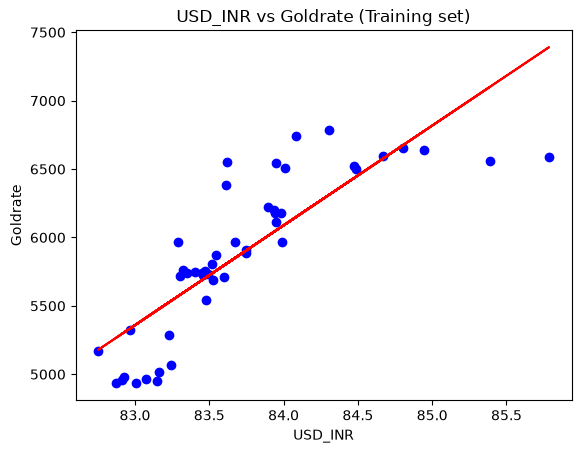

In [35]:
plt.scatter(x_train,y_train,color='blue')
plt.plot(x_train,x_train_predicted,color='red')
plt.xlabel('USD_INR')
plt.ylabel('Goldrate')
plt.title('USD_INR vs Goldrate (Training set)')
plt.show()

In [36]:
x_test_predicted=regressor.predict(x_test_scaled)


In [37]:
x_test_predicted

array([[5702.05943009],
       [6127.70978702],
       [6494.65358787],
       [5645.83421639],
       [6155.1992781 ],
       [5348.52935023]])

In [38]:
y_test

,Goldrate
19,5754.39
41,6563.33
47,6524.06
12,5341.21
43,6795.35
5,4953.90


In [39]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [40]:
MSE=mean_squared_error(y_test,x_test_predicted)
MAE=mean_absolute_error(y_test,x_test_predicted)
R2=r2_score(y_test,x_test_predicted)
MSE,MAE,R2

(141948.22993388725, 309.4602472570902, 0.697171694089544)

# HYPERPARAMETER OPTIMIZATION

In [41]:
from sklearn.model_selection import RandomizedSearchCV
param_space={'copy_X': [True,False], 
               'fit_intercept': [True,False], 
               'n_jobs': [1,5,10,15,None], 
               'positive': [True,False]}

In [42]:
search = RandomizedSearchCV(regressor, param_space, n_iter=50, cv=5)

In [43]:
search.fit(x_train_scaled, y_train)

c:\Users\Varshini D\Desktop\DATA_SCIENCE_PROJECTS\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 40 is smaller than n_iter=50. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'copy_X': [True, False], 'fit_intercept': [True, False], 'n_jobs': [1, 5, ...], 'positive': [True, False]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_c

In [44]:
search.best_params_

{'positive': True, 'n_jobs': 1, 'fit_intercept': True, 'copy_X': True}

In [45]:
tuned_model = LinearRegression(positive= True, n_jobs= 1, fit_intercept= True, copy_X= True)

In [46]:
tuned_model.fit(x_train_scaled, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[469.21]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[5878.57]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1


In [47]:
tuned_model.coef_

array([[469.20755762]])

In [48]:
tuned_model.intercept_

array([5878.57340426])

In [49]:
import pickle

In [50]:
pickle.dump(regressor, open('regressor.pkl', 'wb'))
regressor_reloded=pickle.load(open('regressor.pkl', 'rb'))


In [51]:
regressor_reloded.coef_

array([[469.20755762]])

In [52]:
pickle.dump(scaler, open('scaler.pkl', 'wb'))
scaler_reloaded=pickle.load(open('scaler.pkl', 'rb'))

In [53]:
import numpy as np

In [54]:
def calculate_gold_price(usd_inr_value):
    scaled_input=scaler.transform(np.array(usd_inr_value).reshape(1,-1))
    prediction=regressor.predict(scaled_input)
    return float(prediction[0][0])

In [55]:
calculate_gold_price(80)

c:\Users\Varshini D\Desktop\DATA_SCIENCE_PROJECTS\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


3171.5742748744997

In [56]:
import gradio as gr

c:\Users\Varshini D\Desktop\DATA_SCIENCE_PROJECTS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [57]:
demo = gr.Interface(
    fn=calculate_gold_price,
    inputs=["number"],
    outputs=["number"],
    title="How much is 1g gold now in INR based on USD to INR exchange rate?"
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


c:\Users\Varshini D\Desktop\DATA_SCIENCE_PROJECTS\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
